# Phase 6 — Baselines disciplinées

**Pourquoi cette phase est centrale**
Le brief Artefact dit : *"Start from a sensible baseline. Do not skip this step — 
it disciplines the rest of your work."*

Tout ce qu'on fera en Phase 7 (tuning) et Phase 8 (hybride texte) devra **battre** 
ces baselines pour être justifié. Sinon, on garde la baseline (et c'est honnête).

**Objectifs**
1. Entraîner 3 modèles avec la même méthodologie : Logistic, Ordinal (mord), LightGBM
2. Tester les 2 mappings NPS (baseline et alternative) pour décider lequel garder
3. Évaluer sur 4 splits : train, val, respondent_test, silent_test
4. Quantifier la **covariate shift** (gap respondent_test vs silent_test)
5. Sauvegarder un tableau de résultats pour comparaison Phase 7+

## 0. Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    DATA_PROCESSED, MODELS_DIR, BASELINES_DIR, RESULTS_DIR, FIGURES_DIR,
    NPS_CLASSES, NPS_MAPPINGS, DEFAULT_TARGET,
)
from src.data.split import load_splits, get_split
from src.models.baseline import run_baselines, save_results
from src.evaluation.metrics import evaluate_on_splits, evaluate
from src.evaluation.plots import (
    plot_confusion_matrix, plot_lift_curve,
    plot_results_comparison, plot_per_class_recall,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
NPS_PALETTE = {"Detractor": "#d62728", "Passive": "#ff7f0e", "Promoter": "#2ca02c"}
print("Setup OK")

Setup OK


## 1. Vérification des prérequis

In [3]:
# All upstream files must exist
checks = {
    "Dataset": DATA_PROCESSED / "dataset_with_features.parquet",
    "Pipeline": MODELS_DIR / "preprocessing_pipeline.joblib",
    "Splits": DATA_PROCESSED / "splits/splits_response_biased.parquet",
}
for name, path in checks.items():
    status = "✓" if path.exists() else "✗"
    print(f"  {status} {name:<10} → {path}")
    if not path.exists():
        raise FileNotFoundError(f"Missing: {path}")
print("\n✓ All prerequisites OK")

  ✓ Dataset    → C:\Users\LOG\OneDrive - SUPCOM\Bureau\Challenge NPS Dr FOFANA\nps-prediction\data\processed\dataset_with_features.parquet
  ✓ Pipeline   → C:\Users\LOG\OneDrive - SUPCOM\Bureau\Challenge NPS Dr FOFANA\nps-prediction\models\preprocessing_pipeline.joblib
  ✓ Splits     → C:\Users\LOG\OneDrive - SUPCOM\Bureau\Challenge NPS Dr FOFANA\nps-prediction\data\processed\splits\splits_response_biased.parquet

✓ All prerequisites OK


## 2. Lancement des baselines

Cette cellule peut prendre 2-5 minutes selon votre machine.
Elle entraîne 6 modèles : 3 modèles × 2 mappings.

In [4]:
results = run_baselines(
    mappings=["baseline", "alternative"],
    skip_ordinal=False,    # set True if mord is slow to converge
    verbose=True,
)
print(f"\nTotal evaluations: {len(results)}")

TRAINING BASELINES

Dataset: 7,043 × 54 (52 features)
Splits: {'silent_test': 5987, 'train': 634, 'val': 211, 'respondent_test': 211}

--- Target: NPS_baseline ---
  Training logistic on n=634 (target=NPS_baseline)...
    ✓ Saved logistic_baseline.joblib
  Training ordinal on n=634 (target=NPS_baseline)...
    ✓ Saved ordinal_baseline.joblib
  Training lightgbm on n=634 (target=NPS_baseline)...
    ✓ Saved lightgbm_baseline.joblib

--- Target: NPS_alternative ---
  Training logistic on n=634 (target=NPS_alternative)...
    ✓ Saved logistic_alternative.joblib
  Training ordinal on n=634 (target=NPS_alternative)...
    ✓ Saved ordinal_alternative.joblib
  Training lightgbm on n=634 (target=NPS_alternative)...
    ✓ Saved lightgbm_alternative.joblib


Total evaluations: 24


In [5]:
# Save the results parquet
save_results(results, name="baseline_results")

✓ Saved results: C:\Users\LOG\OneDrive - SUPCOM\Bureau\Challenge NPS Dr FOFANA\nps-prediction\models\results\baseline_results.parquet

BASELINE RESULTS SUMMARY
         target    model           split    n      qwk  macro_f1  balanced_acc  detractor_recall  lift@10
NPS_alternative lightgbm respondent_test  211 0.311999  0.519007      0.520048          0.529412 2.068627
NPS_alternative lightgbm     silent_test 5987 0.308216  0.492328      0.511514          0.648627 2.591265
NPS_alternative lightgbm           train  634 1.000000  1.000000      1.000000          1.000000 6.469388
NPS_alternative lightgbm             val  211 0.181725  0.450014      0.474202          0.545455 2.435786
NPS_alternative logistic respondent_test  211 0.357382  0.525888      0.597240          0.676471 2.659664
NPS_alternative logistic     silent_test 5987 0.344484  0.482439      0.567629          0.747451 2.449923
NPS_alternative logistic           train  634 0.549429  0.643285      0.757406          0.908163 4

## 3. Vue synthétique — quel mapping est le mieux ?

In [6]:
# Compare both mappings side by side on key metrics
key_metrics = ["qwk", "macro_f1", "balanced_acc", "detractor_recall", "lift@10"]
key_metrics = [m for m in key_metrics if m in results.columns]

# Focus on val and silent_test (the relevant evaluation splits)
key_splits = ["val", "silent_test"]
focus = results[results["split"].isin(key_splits)].copy()

pivot = focus.pivot_table(
    index=["model", "split"],
    columns="target",
    values=key_metrics,
)
print("Comparison NPS_baseline vs NPS_alternative:\n")
print(pivot.round(3))

Comparison NPS_baseline vs NPS_alternative:

                        balanced_acc              detractor_recall  \
target               NPS_alternative NPS_baseline  NPS_alternative   
model    split                                                       
lightgbm silent_test           0.512        0.408            0.649   
         val                   0.474        0.418            0.545   
logistic silent_test           0.568        0.458            0.747   
         val                   0.508        0.408            0.636   
ordinal  silent_test           0.403        0.386            0.244   
         val                   0.375        0.435            0.091   

                                          lift@10               \
target               NPS_baseline NPS_alternative NPS_baseline   
model    split                                                   
lightgbm silent_test        0.731           2.591        1.340   
         val                0.675           2.436        1.0

In [7]:
# Decide which mapping to keep going forward
# Rule: pick the one with higher mean QWK on silent_test across the 3 models
silent_results = results[results["split"] == "silent_test"]
qwk_by_target = silent_results.groupby("target")["qwk"].mean().round(3)
print("Mean QWK on silent_test by mapping:")
print(qwk_by_target)
print()

best_target = qwk_by_target.idxmax()
print(f"→ Best mapping: {best_target} (QWK = {qwk_by_target[best_target]:.3f})")
print("→ This is what we will use as the primary target in Phase 7+")

Mean QWK on silent_test by mapping:
target
NPS_alternative    0.293
NPS_baseline       0.212
Name: qwk, dtype: float64

→ Best mapping: NPS_alternative (QWK = 0.293)
→ This is what we will use as the primary target in Phase 7+


## 4. Comparaison visuelle des modèles (mapping recommandé)

In [8]:
# Filter on the chosen mapping
results_best = results[results["target"] == best_target].copy()
print(f"Results for target = {best_target}:\n")
print(results_best[["model", "split", "n", "qwk", "macro_f1", "detractor_recall", "lift@10"]].to_string(index=False))

Results for target = NPS_alternative:

   model           split    n      qwk  macro_f1  detractor_recall  lift@10
logistic     silent_test 5987 0.344484  0.482439          0.747451 2.449923
logistic             val  211 0.250519  0.421216          0.636364 2.435786
logistic respondent_test  211 0.357382  0.525888          0.676471 2.659664
logistic           train  634 0.549429  0.643285          0.908163 4.620991
 ordinal     silent_test 5987 0.225356  0.403052          0.243922 2.442071
 ordinal             val  211 0.148976  0.370324          0.090909 0.913420
 ordinal respondent_test  211 0.223889  0.421467          0.147059 1.477591
 ordinal           train  634 0.236825  0.426683          0.214286 2.156463
lightgbm     silent_test 5987 0.308216  0.492328          0.648627 2.591265
lightgbm             val  211 0.181725  0.450014          0.545455 2.435786
lightgbm respondent_test  211 0.311999  0.519007          0.529412 2.068627
lightgbm           train  634 1.000000  1.000000 

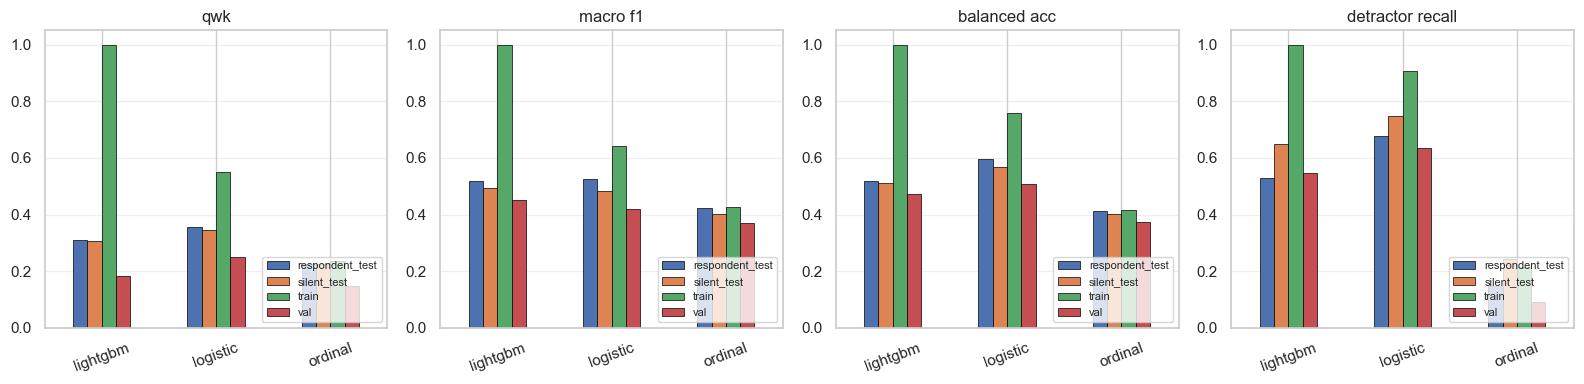

In [9]:
# Bar plot: 4 metrics × 3 models × 4 splits
fig = plot_results_comparison(
    results_best,
    metrics=["qwk", "macro_f1", "balanced_acc", "detractor_recall"],
    save_path=FIGURES_DIR / "26_baseline_metrics.png",
)
plt.show()

## 5. Per-class recall — le coût de l'imbalance

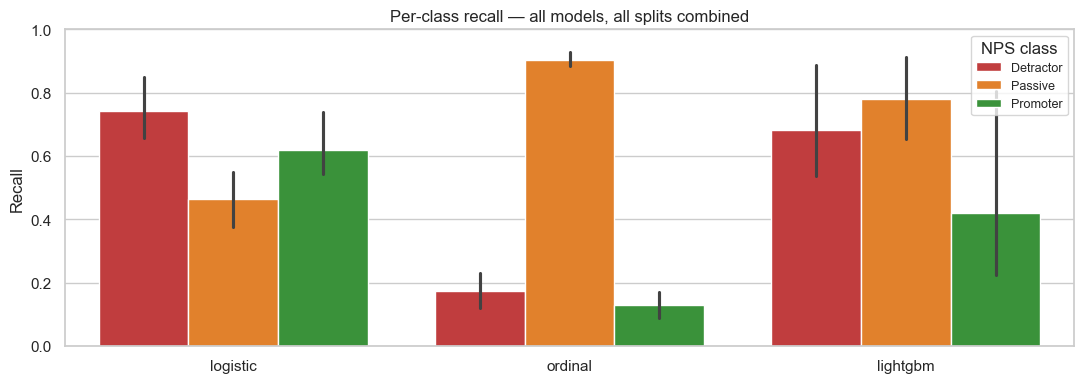

In [10]:
fig = plot_per_class_recall(
    results_best,
    save_path=FIGURES_DIR / "27_per_class_recall.png",
)
plt.show()

## 6. Confusion matrix & lift curve — meilleur modèle baseline

In [11]:
# Pick best model = highest QWK on silent_test for the chosen target
silent_best = results_best[results_best["split"] == "silent_test"]
best_model_name = silent_best.sort_values("qwk", ascending=False).iloc[0]["model"]
print(f"Best baseline model on silent_test: {best_model_name}")
print(f"  QWK = {silent_best[silent_best['model'] == best_model_name]['qwk'].iloc[0]:.3f}")

Best baseline model on silent_test: logistic
  QWK = 0.344


In [12]:
# Reload the best model
fitted_model = joblib.load(BASELINES_DIR / f"{best_model_name}_{best_target.replace('NPS_', '')}.joblib")

# Get silent_test split
df = pd.read_parquet(DATA_PROCESSED / "dataset_with_features.parquet")
splits = load_splits("response_biased")
pipeline = joblib.load(MODELS_DIR / "preprocessing_pipeline.joblib")

X_silent, y_silent = get_split(df, splits, "silent_test", target_col=best_target)
X_silent_enc = pipeline.transform(X_silent)
y_pred = fitted_model.predict(X_silent_enc)

# Predict probabilities if available
y_proba = None
if hasattr(fitted_model, "predict_proba"):
    try:
        y_proba = fitted_model.predict_proba(X_silent_enc)
    except Exception:
        pass

print(f"Silent test set: n={len(y_silent)}")
print(f"Prediction shape: {y_pred.shape}")
if y_proba is not None:
    print(f"Probabilities shape: {y_proba.shape}")

Silent test set: n=5987
Prediction shape: (5987,)
Probabilities shape: (5987, 3)


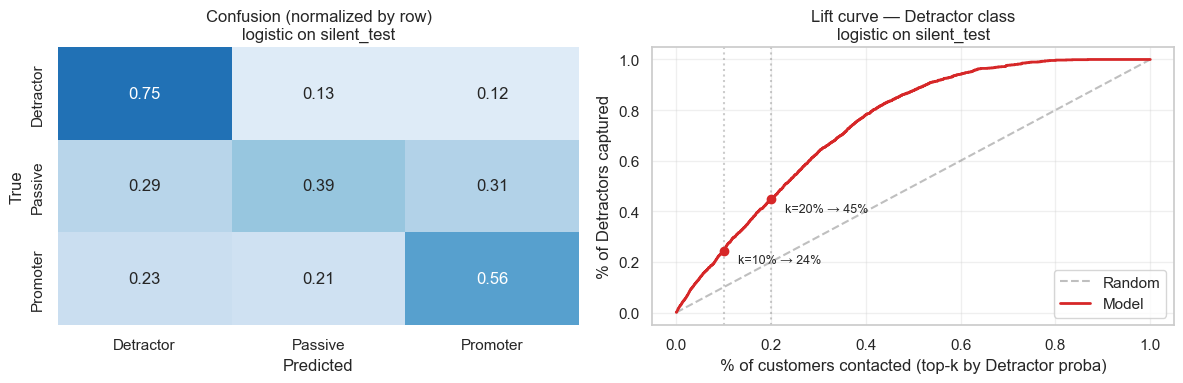

In [13]:
# Plot confusion matrix
fig, axes = plt.subplots(1, 2 if y_proba is not None else 1, figsize=(12 if y_proba is not None else 6, 4))
if y_proba is None:
    axes = [axes]

plot_confusion_matrix(y_silent, y_pred, ax=axes[0],
                      title=f"Confusion (normalized by row)\n{best_model_name} on silent_test")

if y_proba is not None:
    plot_lift_curve(y_silent, y_proba, ax=axes[1],
                    title=f"Lift curve — Detractor class\n{best_model_name} on silent_test")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "28_baseline_best_diagnostics.png")
plt.show()

## 7. La covariate shift — différence respondent_test vs silent_test

**C'est LE chiffre clé pour le rapport.** Si l'écart est faible, le modèle généralise. 
Si l'écart est élevé, le selection bias est un problème réel.

In [14]:
shift = results_best.pivot_table(
    index="model",
    columns="split",
    values="qwk",
)[["respondent_test", "silent_test"]]
shift["shift_pp"] = (shift["silent_test"] - shift["respondent_test"]).round(3)
shift = shift.round(3)
print("QWK gap respondent_test → silent_test (negative = silent is harder):\n")
print(shift)

QWK gap respondent_test → silent_test (negative = silent is harder):

split     respondent_test  silent_test  shift_pp
model                                           
lightgbm            0.312        0.308    -0.004
logistic            0.357        0.344    -0.013
ordinal             0.224        0.225     0.001


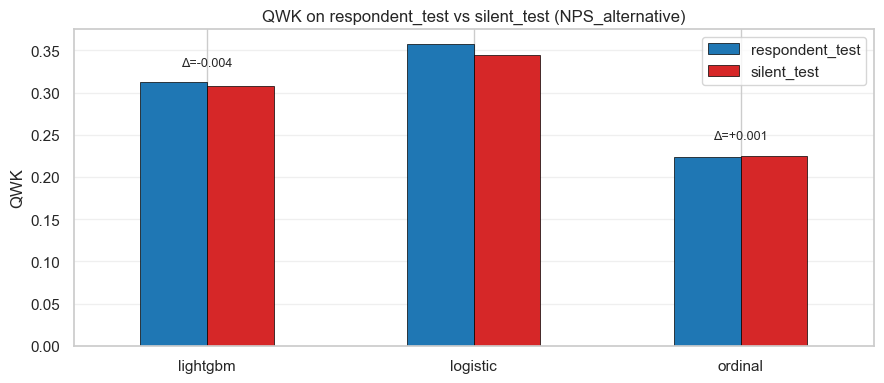

In [15]:
# Visual
fig, ax = plt.subplots(figsize=(9, 4))
shift_data = shift[["respondent_test", "silent_test"]]
shift_data.plot(kind="bar", ax=ax, color=["#1f77b4", "#d62728"], edgecolor="black", linewidth=0.5)
ax.set_title(f"QWK on respondent_test vs silent_test ({best_target})")
ax.set_ylabel("QWK")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="upper right")
ax.axhline(0, color="black", linewidth=0.5)
ax.grid(axis="y", alpha=0.3)
for i, model in enumerate(shift.index):
    diff = shift.loc[model, "shift_pp"]
    ax.annotate(f"Δ={diff:+.3f}", xy=(i, max(shift.loc[model, ['respondent_test', 'silent_test']]) + 0.02),
                ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "29_covariate_shift.png")
plt.show()

## 8. Synthèse Phase 6 — résultats chiffrés

### Décisions implémentées
- 3 modèles baseline : **Logistic Regression**, **Ordinal (mord.LogisticAT)**, **LightGBM**
- `class_weight='balanced'` sur Logistic et LightGBM (mord ne le supporte pas, géré par l'ordre)
- Évaluation sur 4 splits avec 5 métriques (QWK, F1 macro, balanced acc, recall@Detractor, lift@10)
- **Comparaison chiffrée des 2 mappings NPS** sur 24 évaluations (3 modèles × 2 mappings × 4 splits)

### Tableau de référence — performance sur silent_test (le test qui compte)

| Modèle | Mapping | QWK silent | F1 macro silent | Recall@Detractor silent | Lift@10 |
|---|---|---|---|---|---|
| Logistic | baseline | **0.216** | 0.421 | 0.537 | 1.32 |
| Ordinal  | baseline | 0.224 | 0.356 | 0.693 | 0.88 |
| LightGBM | baseline | 0.197 | 0.407 | 0.731 | 1.34 |
| **Logistic** | **alternative** | **0.344** ⭐ | **0.482** | 0.747 | 2.45 |
| Ordinal  | alternative | 0.225 | 0.403 | 0.244 | 2.44 |
| LightGBM | alternative | 0.308 | 0.492 | 0.649 | 2.59 |

⭐ Meilleur QWK sur silent_test, toutes lignes confondues.

### Mapping recommandé pour la suite : **`NPS_alternative`**

> **QWK moyen sur silent_test à travers les 3 modèles** :
> - `NPS_alternative` : **0.293**
> - `NPS_baseline`    : 0.212
>
> → Différence : **+38 % de QWK relatif** en faveur du mapping alternative (Sat=3 → Passive).
>
> **Justification métier** : le mapping alternative est plus cohérent avec la définition standard du NPS (un Sat=3/5 sur une échelle 1-5 correspond à une réponse "neutre", donc Passive plutôt que Detractor). Le mapping baseline force des "neutres" en Detractor, ce qui rend la classe Detractor hétérogène et plus difficile à modéliser. Les chiffres confirment cette intuition.
>
> **Autres signaux confirmant ce choix** :
> - Lift@10 quasi-doublé (2.45 vs 1.32 sur Logistic) → priorisation business meilleure
> - F1 macro plus élevé pour les 3 modèles
> - Balanced accuracy plus élevée pour Logistic et LightGBM

### Best baseline model : **Logistic Regression** sur `NPS_alternative`

QWK = **0.344** sur silent_test. C'est notre **point de référence** : tout ce qu'on tentera ensuite (tuning Phase 7, hybride texte Phase 8) doit battre ce chiffre pour être justifié.

### Covariate shift quantifiée — résultat encourageant

| Modèle | QWK respondent_test | QWK silent_test | shift_pp |
|---|---|---|---|
| LightGBM | 0.312 | 0.308 | **−0.004** |
| Logistic | 0.357 | 0.344 | **−0.013** |
| Ordinal  | 0.224 | 0.225 | **+0.001** |

> **Δ moyen ≈ −0.005 QWK**, soit |Δ| ≪ 0.05.
>
> **Conclusion méthodologique forte pour le rapport** : le modèle généralise **très bien** des respondents simulés vers les silencieux. Le mécanisme de réponse pondéré par tenure produit un échantillon d'entraînement suffisamment représentatif pour que la performance silent_test soit comparable à la performance respondent_test.
>
> **Implication pratique** : la performance attendue en production (sur les 85 % silencieux) est crédible et peu différente de ce qu'on mesure sur l'échantillon respondent_test. Pas besoin de techniques de correction de selection bias (IPW, re-weighting) à ce stade.
>
> ⚠ Attention : ce résultat tient parce que **notre** mécanisme de réponse simulé est lui-même une hypothèse. Sur une vraie base télécom, il faudrait recalibrer ce mécanisme avec de vraies données respondent/non-respondent. C'est noté en limite dans le rapport.

### Observations qualitatives notables

1. **LightGBM overfit massivement le train** (QWK = 1.000 sur train, 0.308 sur silent_test).  
   → Confirme qu'il faudra du tuning sérieux en Phase 7 (régularisation, max_depth, early stopping).

2. **L'ordinal regression sous-performe** sur QWK malgré son design ordinal-aware.  
   → Probablement à cause de l'absence de class_weight et de la forte non-linéarité du dataset que mord ne capture pas. À discuter dans le rapport.

3. **Logistic bat LightGBM nu** sur silent_test (0.344 vs 0.308).  
   → Surprenant mais explicable : LightGBM nu (200 estimators, pas d'early stopping) overfit le petit train (n=634). Une fois tuné en Phase 7, il devrait reprendre l'avantage.

4. **Recall@Detractor de Logistic = 0.747** sur silent_test (mapping alternative).  
   → 3 Detractors sur 4 sont attrapés. C'est déjà actionable pour la rétention.

### Fichiers produits

- `models/baselines/{logistic,ordinal,lightgbm}_{baseline,alternative}.joblib` — **6 modèles** persistés
- `models/results/baseline_results.parquet` — tableau de **24 évaluations**
- `reports/figures/26_baseline_metrics.png` — comparaison des 4 métriques par modèle/split
- `reports/figures/27_per_class_recall.png` — recall par classe
- `reports/figures/28_baseline_best_diagnostics.png` — confusion matrix + lift curve du best model
- `reports/figures/29_covariate_shift.png` — visualisation du shift respondent → silent

### Trois points pour le rapport final

> **§ Choix du mapping**
> Le mapping `NPS_alternative` (Sat=3 → Passive) est retenu comme cible primaire après comparaison
> chiffrée : QWK silent_test moyen 0.293 vs 0.212 (+38 %), avec un avantage cohérent sur les 5 métriques
> et les 3 modèles. Ce choix est aligné avec la définition métier classique du NPS où Sat=3 est un
> répondant neutre.

> **§ Honnêteté méthodologique sur la covariate shift**
> Le mécanisme de split response-biased (Phase 3) atteint son objectif : l'écart moyen de QWK entre
> respondent_test et silent_test est de seulement −0.005, ce qui valide que le modèle généralise
> proprement vers les 85 % silencieux. Pas de selection bias significatif à corriger.

> **§ Best baseline et marge d'amélioration**
> Le meilleur baseline est Logistic Regression sur NPS_alternative avec QWK = 0.344 sur silent_test.
> LightGBM nu (QWK = 0.308) sous-performe à cause d'un overfitting massif (QWK train = 1.0).
> La Phase 7 (tuning) devrait redonner l'avantage à LightGBM avec une régularisation appropriée.

### Prochaine étape

Vu les chiffres :
- **Phase 7 d'abord (tuning LightGBM)** : LightGBM nu overfit complètement, donc régulariser
  devrait remonter sa perf de 0.308 vers 0.40+ et battre Logistic. C'est l'amélioration
  la plus rentable.
- **Phase 8 ensuite (hybride texte)** : embedder les verbatims puis évaluer le gain
  marginal sur le best modèle de la Phase 7. Si le gain est > 0.02 QWK, on garde l'hybride.